# 03 — SARIMA, SARIMAX y boosting: comparación diaria controlada

Este ensayo estudia tres series comerciales de mayor volumen histórico con al menos 120 reportes en 2025, elegidas antes de evaluar 2026. No representa una validación SARIMA de toda la finca. Se emiten siete días en el primer origen disponible de cada mes de 2026 para esas series. Se comparan sobre exactamente los mismos días observados con los resultados del boosting y los repartos de 02.

SARIMA fijo (1,0,1)×(0,1,1,7), en log(1+tallos), ventana de 365 días. SARIMAX añade temperatura, humedad y radiación **rezagadas siete días**: las siete exógenas futuras están ya observadas al origen. No se introduce clima futuro realizado ni se inventa un pronóstico meteorológico. Imputación y estandarización de exógenas usan sólo train.

Se conservan faltantes en la serie endógena; se registran convergencia, fallos y cobertura. No hay búsqueda masiva de órdenes. La referencia es la semana anterior, con media observada de 28 días como respaldo cuando falta ese día. Cada SARIMA se estudia autónomo y también reconciliado al mismo total semanal usado en 02.

Implementación: [documentación oficial SARIMAX de statsmodels](https://www.statsmodels.org/stable/generated/statsmodels.tsa.statespace.sarimax.SARIMAX.html). La inferencia de modelos y la falta de convergencia no son resultados operativos certificados.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'Datos_analiticos_proyecto').is_dir())
DATOS=ROOT/'Datos_analiticos_proyecto'
SALIDA=DATOS/'modelo_diario'
SALIDA.mkdir(exist_ok=True)
KEY=['finca','producto','color','variedad']
pd.set_option('display.max_columns',30)

import warnings
import statsmodels
from statsmodels.tsa.statespace.sarimax import SARIMAX
from threadpoolctl import threadpool_limits
panel=pd.read_parquet(SALIDA/'produccion_clima_diaria.parquet')
semanales=pd.read_parquet(DATOS/'modelo_con_proyecciones_teoricas'/'comparacion_features_diarias_2026.parquet')
semanales=semanales.loc[semanales.horizonte.eq(1)]
print('statsmodels:',statsmodels.__version__)


statsmodels: 0.15.0


## 1. Selección previa, frecuencia y variables exógenas

In [2]:
hist=panel.loc[panel.fecha.ge('2025-01-01')&panel.fecha.lt('2026-01-01')]
ranking=hist.groupby(KEY).agg(tallos=('tallos','sum'),reportes=('observado','sum'))
seleccion=ranking.loc[ranking.reportes.ge(120)].sort_values('tallos',ascending=False).head(3).reset_index()
assert len(seleccion)==3
display(seleccion)
origenes=semanales.groupby(semanales.origen.dt.to_period('M')).origen.min().tolist()
clima=panel.groupby('fecha')[['temperatura','humedad','radiacion']].first().sort_index()
clima=clima.reindex(pd.date_range(panel.fecha.min(),panel.fecha.max(),freq='D'))
exog=clima.shift(7)
exog.columns=[c+'_lag7' for c in exog]
resultados=[];controles=[]


,finca,producto,color,variedad,tallos,reportes
0,GAITANA,MINICARNATION,ORANGE,UCHUVA,3017138,315
1,GAITANA,MINICARNATION,LIGHT PINK,ACADEMY,2239917,315
2,GAITANA,MINICARNATION,YELLOW,CAESAR,2187627,315


## 2. Ajustes por origen y auditoría de convergencia

Un intento adicional de optimización sólo resuelve convergencia, sin comparar errores de test. Un ajuste no convergente no entra en las métricas SARIMA: permanece identificado y se informa cuánto reduce la población común.

In [3]:
for fila in seleccion.itertuples(index=False,name=None):
    clave=fila[:len(KEY)]
    mascara=np.ones(len(panel),dtype=bool)
    ms=np.ones(len(semanales),dtype=bool)
    for c,v in zip(KEY,clave):mascara &= panel[c].eq(v).to_numpy();ms &= semanales[c].eq(v).to_numpy()
    serie=panel.loc[mascara].set_index('fecha').tallos.sort_index()
    referencias=semanales.loc[ms].set_index('origen')
    for origen in origenes:
        if origen not in referencias.index:continue
        fechas=pd.date_range(origen-pd.Timedelta(days=365),origen-pd.Timedelta(days=1),freq='D')
        futuras=pd.date_range(origen,periods=7,freq='D')
        assert (futuras-pd.Timedelta(days=7)).max()<origen
        y=serie.reindex(fechas).astype(float)
        if y.notna().sum()<120:continue
        xt=exog.reindex(fechas).astype(float);xf=exog.reindex(futuras).astype(float)
        med=xt.median().fillna(0);escala=xt.std().replace(0,1).fillna(1)
        xt=(xt.fillna(med)-med)/escala;xf=(xf.fillna(med)-med)/escala
        pronostico=referencias.loc[origen,'Sistema_diario']
        salida=pd.DataFrame({'origen':origen,'fecha':futuras,'tallos':serie.reindex(futuras).to_numpy(dtype=float),'pronostico_semanal':pronostico})
        for c,v in zip(KEY,clave):salida[c]=v
        base=serie.reindex(futuras-pd.Timedelta(days=7)).to_numpy(dtype=float)
        respaldo=serie.loc[(serie.index<origen)&(serie.index>=origen-pd.Timedelta(days=28))].mean()
        salida['Semana_anterior']=np.where(np.isfinite(base),base,respaldo)
        for nombre,usar_x in [('SARIMA',False),('SARIMAX',True)]:
            estado='correcto';mensaje='';p=np.full(7,np.nan);convergio=False
            try:
                with warnings.catch_warnings(record=True) as avisos,threadpool_limits(limits=2):
                    warnings.simplefilter('always')
                    modelo=SARIMAX(np.log1p(y),exog=xt if usar_x else None,order=(1,0,1),seasonal_order=(0,1,1,7),trend='n',enforce_stationarity=False,enforce_invertibility=False)
                    ajuste=modelo.fit(disp=False,maxiter=60)
                    if not ajuste.mle_retvals.get('converged',False):ajuste=modelo.fit(start_params=ajuste.params,disp=False,maxiter=120)
                    convergio=bool(ajuste.mle_retvals.get('converged',False))
                    if convergio:
                        p=np.maximum(0,np.expm1(np.asarray(ajuste.forecast(7,exog=xf if usar_x else None))))
                        if not np.isfinite(p).all():p[:]=np.nan;estado='prediccion_no_finita'
                    else:estado='sin_convergencia'
                    mensaje=' | '.join(sorted(set(str(a.message) for a in avisos)))[:600]
            except (ValueError,np.linalg.LinAlgError,RuntimeError) as exc:estado=type(exc).__name__;mensaje=str(exc)
            salida[nombre]=p
            salida[nombre+'_reconciliado']=p/p.sum()*pronostico if np.isfinite(p).all() and p.sum()>0 else np.full(7,np.nan)
            controles.append(dict(zip(KEY,clave))|{'origen':origen,'modelo':nombre,'estado':estado,'convergio':convergio,'reportes_train':int(y.notna().sum()),'mensaje':mensaje})
        resultados.append(salida)
        print(clave[-1],origen.date(),'evaluado',flush=True)
pred=pd.concat(resultados,ignore_index=True)
auditoria=pd.DataFrame(controles)
display(auditoria.groupby(['modelo','estado']).size().rename('ajustes'))
display(auditoria.loc[~auditoria.convergio])
for m in ['SARIMA_reconciliado','SARIMAX_reconciliado']:
    ok=pred.groupby(KEY+['origen'])[m].count().eq(7)
    suma=pred.groupby(KEY+['origen'])[m].sum()
    total=pred.groupby(KEY+['origen']).pronostico_semanal.first()
    assert np.allclose(suma[ok],total[ok])


UCHUVA 2026-01-05 evaluado


UCHUVA 2026-02-02 evaluado


UCHUVA 2026-03-02 evaluado


UCHUVA 2026-04-06 evaluado


UCHUVA 2026-05-04 evaluado


...

CAESAR 2026-06-01 evaluado


CAESAR 2026-07-06 evaluado


CAESAR 2026-08-03 evaluado


modelo   estado          
SARIMA   correcto            23
         sin_convergencia     1
SARIMAX  correcto            24
Name: ajustes, dtype: int64

,finca,producto,color,variedad,origen,modelo,estado,convergio,reportes_train,mensaje
42,GAITANA,MINICARNATION,YELLOW,CAESAR,2026-06-01,SARIMA,sin_convergencia,False,311,Maximum Likelihood optimization failed to conv...


## 3. Comparación con boosting y perfil sobre población idéntica

Días con reporte: 141 ; comunes a todos: 135


,n,MAE,RMSE,WAPE,sesgo
metodo,,,,,
Boosting_diario,135.0,2789.068408,3691.773143,0.308484,1120.814900
Boosting_reconciliado,135.0,2720.137613,3666.916124,0.300860,1309.422515
Perfil_8semanas,135.0,2707.807733,3657.771844,0.299496,1329.792328
SARIMA,135.0,2252.108548,3060.919575,0.249094,235.593344
SARIMAX,135.0,2214.360678,3039.691113,0.244919,262.904956
SARIMAX_reconciliado,135.0,2946.486339,4057.243478,0.325895,2207.757692
SARIMA_reconciliado,135.0,2924.436419,4036.088231,0.323457,2196.062081
Semana_anterior,135.0,2839.949850,3912.705928,0.314112,259.541937
Uniforme_semanal,135.0,2938.868744,4078.350291,0.325053,2238.137048


n          MAE         RMSE      WAPE  \
variedad metodo                                                            
ACADEMY  Boosting_diario        47.0  2319.294919  3046.001907  0.328122   
         Boosting_reconciliado  47.0  2401.370327  3051.014422  0.339734   
         Perfil_8semanas        47.0  2376.667592  3028.611317  0.336239   
         SARIMA                 47.0  1805.248356  2193.858337  0.255398   
         SARIMAX                47.0  1772.929324  2156.425709  0.250825   
         SARIMAX_reconciliado   47.0  2420.990971  3216.771721  0.342510   
         SARIMA_reconciliado    47.0  2416.412278  3207.890704  0.341862   
         Semana_anterior        47.0  2109.025638  2605.485574  0.298375   
         Uniforme_semanal       47.0  2460.364731  3228.050872  0.348080   
CAESAR   Boosting_diario        41.0  2305.293130  3358.595660  0.272950   
         Boosting_reconciliado  41.0  2060.322042  3057.087244  0.243945   
         Perfil_8semanas        41.0  2076.127410  3001.953785  0.245816   
         SARIMA                 41.0  2102.440749  3053.661842  0.248932   
         SARIMAX                41.0  2123.574300  3090.541372  0.251434   
         SARIMAX_reconciliado   41.0  2497.190468  3494.955267  0.295671   
         SARIMA_reconciliado    41.0  2484.529579  3469.521656  0.294172   
         Semana_anterior        41.0  2420.610766  3400.140188  0.286603   
         Uniforme_semanal       41.0  2439.073623  3549.052560  0.288789   
UCHUVA   Boosting_diario        47.0  3680.858629  4475.421652  0.319149   
         Boosting_reconciliado  47.0  3614.488696  4600.095995  0.313394   
         Perfil_8semanas        47.0  3589.988157  4625.592896  0.311270   
         SARIMA                 47.0  2829.530011  3736.864408  0.245334   
         SARIMAX                47.0  2734.988659  3682.029729  0.237137   
         SARIMAX_reconciliado   47.0  3863.920658  5126.327472  0.335021   
         SARIMA_reconciliado    47.0  3816.209080  5098.923240  0.330884   
         Semana_anterior        47.0  3936.680499  5205.745522  0.341330   
         Uniforme_semanal       47.0  3853.364246  5134.915165  0.334106   

                                      sesgo  
variedad metodo                              
ACADEMY  Boosting_diario         912.418886  
         Boosting_reconciliado   549.500363  
         Perfil_8semanas         582.539815  
         SARIMA                   75.764973  
         SARIMAX                  87.720080  
         SARIMAX_reconciliado   1274.132853  
         SARIMA_reconciliado    1267.263212  
         Semana_anterior          26.637637  
         Uniforme_semanal       1323.836905  
CAESAR   Boosting_diario        1549.344614  
         Boosting_reconciliado  1441.573100  
         Perfil_8semanas        1471.793916  
         SARIMA                  804.952120  
         SARIMAX                 837.212022  
         SARIMAX_reconciliado   2257.152306  
         SARIMA_reconciliado    2266.205699  
         Semana_anterior         992.118820  
         Uniforme_semanal       2290.802242  
UCHUVA   Boosting_diario         955.387120  
         Boosting_reconciliado  1954.064369  
         Perfil_8semanas        1953.171116  
         SARIMA                 -101.252961  
         SARIMAX                 -62.901439  
         SARIMAX_reconciliado   3098.293612  
         SARIMA_reconciliado    3063.671836  
         Semana_anterior        -146.610193  
         Uniforme_semanal       3106.495213

n          MAE         RMSE      WAPE  \
origen     metodo                                                            
2026-01-05 Boosting_diario        18.0  1036.596905  1272.619957  0.241375   
           Boosting_reconciliado  18.0  1226.705130  1649.294518  0.285642   
           Perfil_8semanas        18.0  1309.161250  1676.402733  0.304842   
           SARIMA                 18.0  1198.087567  1474.285118  0.278978   
           SARIMAX                18.0  1060.011563  1313.022798  0.246827   
...                                ...          ...          ...       ...   
2026-08-03 SARIMAX                15.0  2968.256494  3968.563243  0.292468   
           SARIMAX_reconciliado   15.0  3547.768595  4922.425861  0.349568   
           SARIMA_reconciliado    15.0  3655.794484  4952.138935  0.360212   
           Semana_anterior        15.0  2854.533333  4019.595751  0.281263   
           Uniforme_semanal       15.0  4065.539127  5356.695813  0.400585   

                                        sesgo  
origen     metodo                              
2026-01-05 Boosting_diario         109.379726  
           Boosting_reconciliado  -775.264635  
           Perfil_8semanas        -812.484851  
           SARIMA                 -951.784542  
           SARIMAX                -657.351766  
...                                       ...  
2026-08-03 SARIMAX                1446.782241  
           SARIMAX_reconciliado   2824.001078  
           SARIMA_reconciliado    2810.447148  
           Semana_anterior        2051.600000  
           Uniforme_semanal       2527.157089  

[72 rows x 5 columns]

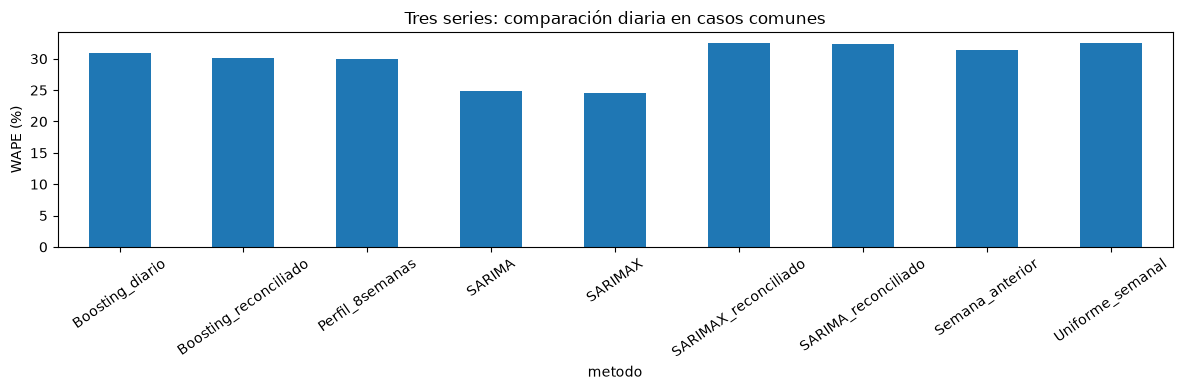

No extrapolar los resultados de estas tres series a toda la finca. SARIMAX se compara con clima pasado, no clima futuro observado.


In [4]:
boost=pd.read_parquet(SALIDA/'predicciones_diarias_2026.parquet')
cols=['Uniforme_semanal','Perfil_8semanas','Boosting_diario','Boosting_reconciliado']
pred=pred.merge(boost[KEY+['origen','fecha']+cols],on=KEY+['origen','fecha'],how='left',validate='one_to_one')
metodos=['Semana_anterior','SARIMA','SARIMAX','SARIMA_reconciliado','SARIMAX_reconciliado']+cols
comunes=pred.loc[pred.tallos.notna()&pred[metodos].notna().all(axis=1)].copy()
assert len(comunes)>0,'No hay casos comunes: revisar auditoría de convergencia.'
print('Días con reporte:',pred.tallos.notna().sum(),'; comunes a todos:',len(comunes))
larga=comunes.melt(id_vars=KEY+['origen','fecha','tallos'],value_vars=metodos,var_name='metodo',value_name='prediccion')
def evaluar(g):
    e=g.tallos-g.prediccion
    return pd.Series({'n':len(g),'MAE':e.abs().mean(),'RMSE':np.sqrt((e**2).mean()),'WAPE':e.abs().sum()/g.tallos.sum(),'sesgo':e.mean()})
resumen=larga.groupby('metodo').apply(evaluar)
display(resumen)
display(larga.groupby(['variedad','metodo']).apply(evaluar))
display(larga.groupby(['origen','metodo']).apply(evaluar))
resumen.WAPE.mul(100).plot.bar(figsize=(12,4),ylabel='WAPE (%)',rot=35,title='Tres series: comparación diaria en casos comunes');plt.tight_layout();plt.show()
pred.to_parquet(SALIDA/'comparacion_sarima_diaria.parquet',index=False)
with pd.ExcelWriter(SALIDA/'resultados_sarima_diario.xlsx') as w:
    resumen.to_excel(w,sheet_name='Resumen');auditoria.to_excel(w,sheet_name='Convergencia',index=False);seleccion.to_excel(w,sheet_name='Series',index=False);pred.to_excel(w,sheet_name='Predicciones',index=False)
print('No extrapolar los resultados de estas tres series a toda la finca. SARIMAX se compara con clima pasado, no clima futuro observado.')


## Continuación vigente

Diario 04 conserva estos ajustes y evalúa su reconciliación con Memoria_larga semanal. Semanal 17 reconstruye el último origen para diagnosticar train/test de SARIMA/SARIMAX con convergencia y periodo inicial excluido.